Installing Dependencies and Libraries

In [1]:
import os
import re
import json
import glob
import warnings
import textwrap
import pathlib
from collections import defaultdict
import numpy as np
import pandas as pd

#pdf analyzer
import pdfplumber
    
#model
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

#import SHAP and LIME
import shap
import lime
from lime.lime_text import LimeTextExplainer

#matplotlib
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

Global Configs

In [ ]:
DATA_DIR        = r"f:\research project\supreme_court_judgments"
OUTPUT_DIR      = r"f:\research project\outputs"
RANDOM_STATE    = 42
START_YEAR      = 2000        # starting year of the cases of the dataset
END_YEAR        = 2025        # ending year of the cases of the dataset
MAX_PER_YEAR    = 10          # no. of PDFs to load
MIN_TEXT_LEN    = 300         # minimum chars to treat a PDF as valid
TOP_SHAP_FACTS  = 5           # number of key facts to surface per explanation
TFIDF_MAX_FEAT  = 5000
RF_N_ESTIMATORS = 200

Terms List

In [3]:
IPC_SECTIONS = {
    "302": "Murder",
    "304": "Culpable homicide not amounting to murder",
    "304A": "Causing death by negligence",
    "307": "Attempt to murder",
    "376": "Rape",
    "420": "Cheating",
    "498A": "Cruelty by husband / relatives",
    "379": "Theft",
    "395": "Dacoity",
    "406": "Criminal breach of trust",
}

VERDICT_PATTERNS = {
    "Convicted": [
        r"\bconvicted\b", r"\bguilty\b", r"\bsentenced to\b",
        r"\bappeal\s+dismissed\b", r"\bimprisonment for life\b",
        r"\bdeath\s+penalty\b", r"\blife\s+imprisonment\b",
    ],
    "Acquitted": [
        r"\bacquitted\b", r"\bnot\s+guilty\b", r"\bappeal\s+allowed\b",
        r"\bset\s+aside\b.*convict", r"\bdischarged\b",
    ],
    "Remanded": [
        r"\bremanded\b", r"\bremand\b", r"\bfresh\s+trial\b",
        r"\bretrial\b", r"\bde\s+novo\b",
    ],
}

LEGAL_RULES = [
    {
        "condition": {"verdict": "Convicted", "section": "302"},
        "required_patterns": [r"life\s+imprisonment", r"death\s+penalty",
                               r"death\s+sentence", r"imprisonment for life"],
        "description": "IPC 302 conviction must carry life/death sentence.",
    },
    {
        "condition": {"verdict": "Convicted", "section": "376"},
        "required_patterns": [r"\d+\s+years?\s+(?:rigorous\s+)?imprisonment",
                               r"life\s+imprisonment"],
        "description": "IPC 376 conviction must carry imprisonment term.",
    },
    {
        "condition": {"verdict": "Acquitted", "section": None},
        "forbidden_patterns": [r"sentenced to", r"imprisonment for",
                                r"death penalty"],
        "description": "Acquittal cannot co-exist with a punishment sentence.",
    },
]

os.makedirs(OUTPUT_DIR, exist_ok=True)

Extracting Text from PDF

In [4]:
def extract_text_from_pdf(pdf_path: str) -> str:
    text_parts = []
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages[:30]:          # (can change) cap at 30 pages per doc
                pt = page.extract_text()
                if pt:
                    text_parts.append(pt)
    except Exception as exc:
        pass
    return "\n".join(text_parts)

Loading the Dataset

In [5]:
def load_judgments(
    data_dir: str = DATA_DIR,
    max_per_year: int = MAX_PER_YEAR,
    years_range: tuple = (START_YEAR, END_YEAR),
) -> pd.DataFrame:
    records = []
    data_path = pathlib.Path(data_dir)

    print(f"Max Cases per Year: {max_per_year}")
    print(f"Dataset Range     : From {years_range[0]} to {years_range[1]}\n")

    for year in range(years_range[0], years_range[1] + 1):
        year_path = data_path / str(year)
        if not year_path.is_dir():
            continue

        pdf_files = sorted(year_path.glob("*.PDF")) + \
                    sorted(year_path.glob("*.pdf"))

        loaded = 0
        for pdf_file in pdf_files:
            if loaded >= max_per_year:
                break
            text = extract_text_from_pdf(str(pdf_file))
            if len(text) < MIN_TEXT_LEN:
                continue
            case_name = pdf_file.stem.replace("_", " ")
            records.append({
                "filename":  pdf_file.name,
                "year":      year,
                "case_name": case_name,
                "text":      text,
            })
            loaded += 1

        if loaded:
            print(f"From {year}, loaded {loaded} cases or judgments")

    df = pd.DataFrame(records)
    print(f"\nTotal loaded: {len(df)} judgments from a total of"
          f"{df['year'].nunique() if len(df) else 0} years\n")
    return df

#loading
df_raw = load_judgments(
    data_dir=DATA_DIR,
    max_per_year=MAX_PER_YEAR,
    years_range=(START_YEAR, END_YEAR),
)

if df_raw.empty:
    print("[ERROR] No judgments loaded. Stopping pipeline.")
    raise SystemExit

Max Cases per Year: 10
Dataset Range     : From 2000 to 2025

From 2000, loaded 10 cases or judgments
From 2001, loaded 10 cases or judgments
From 2002, loaded 10 cases or judgments
From 2003, loaded 10 cases or judgments
From 2004, loaded 10 cases or judgments
From 2005, loaded 10 cases or judgments
From 2006, loaded 10 cases or judgments
From 2007, loaded 10 cases or judgments
From 2008, loaded 10 cases or judgments
From 2009, loaded 10 cases or judgments
From 2010, loaded 10 cases or judgments
From 2011, loaded 10 cases or judgments
From 2012, loaded 10 cases or judgments
From 2013, loaded 10 cases or judgments
From 2014, loaded 10 cases or judgments
From 2015, loaded 10 cases or judgments
From 2016, loaded 10 cases or judgments
From 2017, loaded 10 cases or judgments
From 2018, loaded 10 cases or judgments
From 2019, loaded 10 cases or judgments
From 2020, loaded 10 cases or judgments
From 2021, loaded 10 cases or judgments
From 2022, loaded 10 cases or judgments
From 2023, loaded 

Lable Extraction and Preprocessiong

In [6]:
def clean_text(text: str) -> str:
    """Normalise whitespace and remove OCR artefacts."""
    text = re.sub(r"\n{2,}", "\n", text)
    text = re.sub(r"[ \t]{2,}", " ", text)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)   # strip non-ASCII
    return text.strip()

In [7]:
def extract_sentences(text: str) -> list:
    """
    Split text into sentences using punctuation-based heuristics
    suitable for legal documents.
    """
    text = clean_text(text)
    # Split on .  !  ?  followed by whitespace + capital letter
    sents = re.split(r"(?<=[.!?])\s+(?=[A-Z])", text)
    # Also split on newlines that end with a period
    result = []
    for s in sents:
        sub = re.split(r"\n(?=[A-Z])", s)
        result.extend(sub)
    return [s.strip() for s in result if len(s.strip()) > 30]

In [8]:
def extract_verdict(text: str) -> str:
    """
    Heuristically extract verdict label from judgment text.
    Returns one of: 'Convicted', 'Acquitted', 'Remanded', 'Unknown'
    """
    text_lower = text.lower()
    scores = defaultdict(int)
    for verdict, patterns in VERDICT_PATTERNS.items():
        for pat in patterns:
            matches = re.findall(pat, text_lower)
            scores[verdict] += len(matches)

    if not any(scores.values()):
        return "Unknown"
    return max(scores, key=scores.get)

In [9]:
def extract_ipc_sections(text: str) -> list:
    """
    Extract IPC/CrPC section references from judgment text.
    Returns list of section strings, e.g. ['302', '304', '376']
    """
    # Pattern: Section 302/304 IPC  or  u/s 302  or  Section 302
    pattern = r"(?:section|u/s|u\.s\.)\s*(\d{2,3}[A-Za-z]?)"
    matches = re.findall(pattern, text, re.IGNORECASE)
    # Also match standalone IPC references: "IPC 302" or "302 IPC"
    pattern2 = r"(\d{3}[A-Za-z]?)\s+(?:IPC|I\.P\.C\.)"
    matches2 = re.findall(pattern2, text, re.IGNORECASE)
    all_sections = list(set(matches + matches2))
    # Filter to known IPC sections
    return [s.upper() for s in all_sections if s.upper() in IPC_SECTIONS or s in IPC_SECTIONS]

In [10]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add verdict, ipc_sections, clean_text, and sentence columns to DataFrame.
    Drops 'Unknown' verdict rows for supervised learning.
    """

    df = df.copy()
    df["clean_text"]   = df["text"].apply(clean_text)
    df["verdict"]      = df["text"].apply(extract_verdict)
    df["ipc_sections"] = df["text"].apply(extract_ipc_sections)
    df["sentences"]    = df["clean_text"].apply(extract_sentences)
    df["sent_count"]   = df["sentences"].apply(len)

    verdict_counts = df["verdict"].value_counts()
    print("Verdict distribution:")
    for v, c in verdict_counts.items():
        bar = "█" * int(c / max(verdict_counts) * 20)
        print(f"    {v:<15} {c:>4}  {bar}")

    # Drop 'Unknown' for supervised training
    df_known = df[df["verdict"] != "Unknown"].copy()
    print(f"\nUsable (labeled) records: {len(df_known)} / {len(df)}")
    print(f"Avg sentences per case  : {df['sent_count'].mean():.0f}\n")
    return df_known
#preprocessing
df = preprocess(df_raw)

Verdict distribution:
    Unknown          126  ████████████████████
    Convicted         82  █████████████
    Remanded          28  ████
    Acquitted         24  ███

Usable (labeled) records: 134 / 260
Avg sentences per case  : 237



Training the Model

In [11]:
def train_model(df: pd.DataFrame):
    """
    Returns:
        model       — trained RandomForestClassifier
        vectorizer  — fitted TfidfVectorizer
        X_test      — test texts
        y_test      — test labels
        report      — classification report string
    """

    X = df["clean_text"].tolist()
    y = df["verdict"].tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
    )
    print(f"Train samples : {len(X_train)}")
    print(f"Test  samples : {len(X_test)}")
    print(f"Classes       : {sorted(set(y))}\n")

    vectorizer = TfidfVectorizer(
        max_features=TFIDF_MAX_FEAT,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2,
        stop_words="english",
    )
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec  = vectorizer.transform(X_test)

    model = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced",
    )
    model.fit(X_train_vec, y_train)

    y_pred   = model.predict(X_test_vec)
    accuracy = accuracy_score(y_test, y_pred)
    report   = classification_report(y_test, y_pred)

    print(f"\nTest Accuracy : {accuracy:.5%}")
    print(f"\nClassification Report:")
    print(textwrap.indent(report, "    "))

    return model, vectorizer, X_test, y_test, report
#model training
# train primary RF model
model, vectorizer, X_test, y_test, report = train_model(df)

# get y_pred for confusion matrix later
from sklearn.feature_extraction.text import TfidfVectorizer as _TFV
y_pred_rf = model.predict(vectorizer.transform(X_test))

if len(df) < 20:
        print(f"[ERROR] Only {len(df)} labeled records. "
              f"Increase MAX_PER_YEAR and retry.")
        raise SystemExit

Train samples : 93
Test  samples : 41
Classes       : ['Acquitted', 'Convicted', 'Remanded']



C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi


Test Accuracy : 63.41463%

Classification Report:
                  precision    recall  f1-score   support

       Acquitted       0.00      0.00      0.00         7
       Convicted       0.62      1.00      0.77        25
        Remanded       1.00      0.11      0.20         9

        accuracy                           0.63        41
       macro avg       0.54      0.37      0.32        41
    weighted avg       0.60      0.63      0.51        41



SHAP Feature Attribution

In [12]:
def compute_shap_contributions(
    model,
    vectorizer,
    text: str,
    top_n: int = TOP_SHAP_FACTS,
) -> list:
    """
    Compute SHAP-based feature attribution for a single judgment text.
    Maps SHAP values back to readable text segments (bigrams/unigrams).
    Returns:
        list of dicts: {text, shap_value, impact}
    """

    text_vec = vectorizer.transform([text])
    feature_names = vectorizer.get_feature_names_out()

    try:
        explainer = shap.TreeExplainer(model)
        # Convert sparse → dense float64 to avoid numpy/scipy type mismatch
        text_vec_dense = text_vec.toarray().astype(np.float64)
        shap_values = explainer.shap_values(text_vec_dense)

        # Determine predicted class index
        pred_class_idx = model.predict(text_vec)[0]
        classes        = list(model.classes_)
        class_idx      = classes.index(pred_class_idx)

        # Handle both shap output shapes:
        #   - list of 2D arrays: shap_values[class][sample, feature]
        #   - 3D ndarray:        shap_values[sample, feature, class]
        if isinstance(shap_values, list):
            sv = np.array(shap_values[class_idx][0], dtype=float)
        elif isinstance(shap_values, np.ndarray):
            if shap_values.ndim == 3:
                sv = shap_values[0, :, class_idx].astype(float)
            else:
                sv = shap_values[0].astype(float)
        else:
            raise ValueError("Unrecognised SHAP output shape.")

        # Only keep features present in the document (tfidf > 0)
        tfidf_row   = text_vec_dense[0]
        active_mask = tfidf_row > 0

        sv_active = sv[active_mask]
        fn_active = feature_names[active_mask]

        top_pos_idx = np.argsort(sv_active)[::-1][:top_n]
        top_neg_idx = np.argsort(sv_active)[:top_n]

        results = []
        seen = set()

        for idx in list(top_pos_idx) + list(top_neg_idx):
            feat  = str(fn_active[idx])
            score = float(sv_active[idx])
            if feat in seen:
                continue
            seen.add(feat)

            snippet = _find_sentence_with_token(text, feat)
            impact  = _score_to_impact(score)
            results.append({
                "text":       snippet or feat,
                "token":      feat,
                "shap_value": round(score, 4),
                "impact":     impact,
            })

        results.sort(key=lambda x: abs(x["shap_value"]), reverse=True)
        return results[:top_n * 2]

    except Exception as exc:
        print(f"  [SHAP] Warning: {exc}. Falling back to TF-IDF weights.")
        return _tfidf_fallback_attribution(vectorizer, text, top_n)


def _find_sentence_with_token(text: str, token: str) -> str:
    """Return the first sentence in text that contains the given token."""
    sentences = extract_sentences(text)
    token_lower = token.lower()
    for s in sentences:
        if token_lower in s.lower():
            # truncate long sentences
            return s[:200] + ("…" if len(s) > 200 else "")
    return token


def _score_to_impact(score: float) -> str:
    if score >= 0.15:   return "High Positive"
    if score >= 0.05:   return "Positive"
    if score <= -0.15:  return "High Negative"
    if score <= -0.05:  return "Negative"
    return "Neutral"

def _tfidf_fallback_attribution(vectorizer, text: str, top_n: int) -> list:
    """Fallback: use raw TF-IDF weights as importance proxy when SHAP fails."""
    text_vec      = vectorizer.transform([text])
    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores  = text_vec.toarray()[0]

    top_indices = np.argsort(tfidf_scores)[::-1][:top_n * 2]
    results = []
    for idx in top_indices:
        if tfidf_scores[idx] == 0:
            continue
        feat    = feature_names[idx]
        score   = float(tfidf_scores[idx])
        snippet = _find_sentence_with_token(text, feat)
        results.append({
            "text":       snippet or feat,
            "token":      feat,
            "shap_value": round(score, 4),
            "impact":     _score_to_impact(score),
        })
    return results[:top_n]

TF-IDF Weight Attention

In [ ]:
def attention_visualization(
    vectorizer,
    text: str,
    top_n: int = 8,
) -> list:
    """
    Use TF-IDF aggregate scores as a proxy for transformer 'attention'.

    Ranks sentences by the sum of their constituent TF-IDF weights.

    Returns:
        list of dicts: {sentence, weight, rank}
    """
    sentences = extract_sentences(text)
    if not sentences:
        return []

    feature_names = vectorizer.get_feature_names_out()
    fn_set        = set(feature_names)

    # Build a per-sentence score: sum(tfidf weight of tokens present in that sentence)
    text_vec      = vectorizer.transform([text])
    tfidf_lookup  = {feature_names[i]: text_vec[0, i]
                     for i in text_vec.nonzero()[1]}

    sent_scores = []
    for s in sentences:
        tokens = re.findall(r"\b[a-z]{3,}\b", s.lower())
        score  = sum(tfidf_lookup.get(t, 0) for t in tokens if t in fn_set)
        sent_scores.append((s, float(score)))

    sent_scores.sort(key=lambda x: x[1], reverse=True)
    top = sent_scores[:top_n]

    results = []
    for rank, (s, w) in enumerate(top, 1):
        results.append({
            "rank":     rank,
            "sentence": s[:200] + ("…" if len(s) > 200 else ""),
            "weight":   round(w, 4),
        })
    return results

Counterfactual Check

In [ ]:
def generate_counterfactual(
    model,
    vectorizer,
    text: str,
    original_pred: str,
    original_sections: list,
) -> dict:
    """
    Find the minimal text change that flips the predicted verdict.

    Strategy: iteratively remove one sentence at a time and check
    whether the prediction changes.

    Returns a dict with counterfactual details or None if none found.
    """
    sentences = extract_sentences(text)
    if len(sentences) < 3:
        return {"found": False, "reason": "Too few sentences to ablate."}

    for i, sent in enumerate(sentences):
        # Build text without sentence i
        modified  = " ".join(sentences[:i] + sentences[i+1:])
        mod_vec   = vectorizer.transform([modified])
        new_pred  = model.predict(mod_vec)[0]

        if new_pred != original_pred:
            # Map section flip if possible
            section_flip = _infer_section_flip(original_pred, new_pred, original_sections)
            return {
                "found":            True,
                "removed_sentence": sent[:250],
                "original_verdict": original_pred,
                "new_verdict":      new_pred,
                "change":           f'Remove: "{sent[:120]}…"',
                "result":           f"Prediction flips from {original_pred} → {new_pred}",
                "section_flip":     section_flip,
                "legal_meaning": (
                    f"If the fact '{sent[:80]}…' were absent from the record, "
                    f"the model would predict {new_pred} instead of {original_pred}. "
                    f"This mirrors hypothetical judicial reasoning."
                ),
            }

    return {
        "found":  False,
        "reason": "No single sentence removal flips the prediction.",
    }

def _infer_section_flip(orig_verdict: str, new_verdict: str, sections: list) -> str:
    
    if orig_verdict == "Convicted" and new_verdict == "Acquitted":
        return "Possible shift from conviction under IPC 302 to acquittal"
    if orig_verdict == "Convicted" and new_verdict == "Remanded":
        if "302" in sections:
            return "Possible reduction: IPC 302 → IPC 304 (culpable homicide)"
        return "Possible remand for fresh trial"
    if orig_verdict == "Acquitted" and new_verdict == "Convicted":
        return "Removal of exculpatory fact may lead to conviction"
    return "Verdict category changes"

Rule Consistency

In [15]:
def rule_consistency_check(
    verdict: str,
    sections: list,
    full_text: str,
) -> dict:
    """
    Validate the prediction against known legal rules.
    """
    flags         = []
    checked_rules = 0
    text_lower    = full_text.lower()

    for rule in LEGAL_RULES:
        cond    = rule["condition"]
        r_sect  = cond.get("section")
        r_verd  = cond.get("verdict")

        # Check if this rule applies
        verdict_match  = (r_verd is None) or (verdict == r_verd)
        section_match  = (r_sect is None) or (r_sect in sections)
        if not (verdict_match and section_match):
            continue

        checked_rules += 1

        # Check required patterns
        if "required_patterns" in rule:
            found = any(re.search(p, text_lower)
                        for p in rule["required_patterns"])
            if not found:
                flags.append(
                    f"RULE VIOLATION: {rule['description']} "
                    f"[Verdict={verdict}, Section(s)={sections}]"
                )

        # Check forbidden patterns
        if "forbidden_patterns" in rule:
            for p in rule["forbidden_patterns"]:
                if re.search(p, text_lower):
                    flags.append(
                        f"FORBIDDEN PATTERN found for {verdict}: "
                        f"'{p}' — {rule['description']}"
                    )

    return {
        "valid":         len(flags) == 0,
        "flags":         flags,
        "checked_rules": checked_rules,
    }

LIME

In [17]:
def lime_predict(texts):
    vec = vectorizer.transform(texts)
    return model.predict_proba(vec)

explainer = LimeTextExplainer(
    class_names=model.classes_
)

exp = explainer.explain_instance(
    df.iloc[0]["clean_text"],
    lime_predict,
    num_features=10
)

print(exp.as_list())

[(np.str_('Indian'), -0.013213549949740866), (np.str_('passed'), -0.012865305731596902), (np.str_('order'), -0.012168243660217487), (np.str_('rights'), -0.011504535489453389), (np.str_('filed'), -0.010837763998174961), (np.str_('Kanoon'), -0.010832096239704166), (np.str_('basis'), -0.010382868601136965), (np.str_('Mr'), -0.00897544452463352), (np.str_('dated'), -0.008920776332737418), (np.str_('000'), 0.008260100741767683)]


Multi Model Comparison

In [ ]:
def compare_models(df: pd.DataFrame) -> pd.DataFrame:
    
    from sklearn.linear_model  import LogisticRegression
    from sklearn.svm           import LinearSVC
    from sklearn.ensemble      import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.metrics       import f1_score, accuracy_score
    from sklearn.calibration   import CalibratedClassifierCV
    import time

    X = df["clean_text"].tolist()
    y = df["verdict"].tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
    )

    vectorizer = TfidfVectorizer(
        max_features=TFIDF_MAX_FEAT, ngram_range=(1, 2),
        sublinear_tf=True, min_df=2, stop_words="english"
    )
    X_train_v = vectorizer.fit_transform(X_train)
    X_test_v  = vectorizer.transform(X_test)

    model_registry = [
        ("Logistic Regression",  LogisticRegression(max_iter=1000, C=1.0,
                                                     class_weight="balanced",
                                                     random_state=RANDOM_STATE)),
        ("Linear SVM",           CalibratedClassifierCV(LinearSVC(max_iter=2000,
                                                        class_weight="balanced",
                                                        random_state=RANDOM_STATE))),
        ("Random Forest",        RandomForestClassifier(n_estimators=RF_N_ESTIMATORS,
                                                        class_weight="balanced",
                                                        random_state=RANDOM_STATE,
                                                        n_jobs=-1)),
        ("Gradient Boosting",    GradientBoostingClassifier(n_estimators=100,
                                                             random_state=RANDOM_STATE)),
    ]

    try:
        from xgboost import XGBClassifier
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        y_train_enc = le.fit_transform(y_train)
        y_test_enc  = le.transform(y_test)
        xgb_model = XGBClassifier(n_estimators=100, eval_metric="mlogloss",
                                   random_state=RANDOM_STATE, verbosity=0,
                                   use_label_encoder=False)
        model_registry.append(("XGBoost", (xgb_model, le, y_train_enc, y_test_enc)))
    except ImportError:
        le = y_train_enc = y_test_enc = None
        print("XGBoost not installed. Use pip install xgboost")

    try:
        from lightgbm import LGBMClassifier
        lgbm_model = LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE,
                                     class_weight="balanced", verbose=-1)
        model_registry.append(("LightGBM", lgbm_model))
    except ImportError:
        print("LightGBM not installed. Use pip install lightgbm")

    #training and evaluating
    results = []
    trained_models = {}

    X_train_dense = X_train_v.toarray()
    X_test_dense  = X_test_v.toarray()

    for entry in model_registry:
        name, clf = entry[0], entry[1]

        # Handle XGBoost special case (tuple)
        if isinstance(clf, tuple) and len(clf) == 4:
            xgb_clf, enc, y_tr_e, y_te_e = clf
            t0 = time.time()
            xgb_clf.fit(X_train_dense, y_tr_e)
            train_time = round(time.time() - t0, 2)
            y_pred_enc = xgb_clf.predict(X_test_dense)
            y_pred     = enc.inverse_transform(y_pred_enc)
        else:
            t0 = time.time()
            clf.fit(X_train_v, y_train)
            train_time = round(time.time() - t0, 2)
            y_pred     = clf.predict(X_test_v)

        acc  = accuracy_score(y_test, y_pred)
        mf1  = f1_score(y_test, y_pred, average="macro",    zero_division=0)
        wf1  = f1_score(y_test, y_pred, average="weighted", zero_division=0)
        row  = {
            "Model":       name,
            "Accuracy":    round(acc, 4),
            "Macro F1":    round(mf1, 4),
            "Weighted F1": round(wf1, 4),
            "Train Time (s)": train_time,
        }
        results.append(row)

        # Store model for later
        if not isinstance(clf, tuple):
            trained_models[name] = clf

    results_df = pd.DataFrame(results)

    # Print comparison table to console
    print(f"\n{'─'*72}")
    print(f"  {'Model':<22} {'Accuracy':>9} {'Macro F1':>9} "
          f"{'Weighted F1':>12} {'Time(s)':>9}")
    print(f"{'─'*72}")
    for _, row in results_df.iterrows():
        print(f"  {row['Model']:<22} {row['Accuracy']:>9.4f} "
              f"{row['Macro F1']:>9.4f} {row['Weighted F1']:>12.4f} "
              f"{row['Train Time (s)']:>9.2f}")

    best = results_df.loc[results_df["Weighted F1"].idxmax()]
    print(f"Best model: {best['Model']}  "
          f"(Weighted F1 = {best['Weighted F1']:.4f})\n")

    return results_df
#comparison of models
results_df = compare_models(df)


────────────────────────────────────────────────────────────────────────
  Model                   Accuracy  Macro F1  Weighted F1   Time(s)
────────────────────────────────────────────────────────────────────────
  Logistic Regression       0.5882    0.5050       0.6063      0.15
  Linear SVM                0.7353    0.5781       0.6918      0.12
  Random Forest             0.6176    0.2545       0.4717      0.44
  Gradient Boosting         0.7941    0.7153       0.7765      9.24
  XGBoost                   0.8824    0.8599       0.8801      1.01
  LightGBM                  0.7941    0.7457       0.7877      0.21
────────────────────────────────────────────────────────────────────────
Best model: XGBoost  (Weighted F1 = 0.8801)



Structuring Output
(need not to be included, finding alternatives)

In [ ]:
def generate_explanation(
    case_text:  str,
    case_name:  str,
    model,
    vectorizer,
    year:       int = None,
) -> dict:
    """
    Output schema:
    {
        case_name, year,
        verdict_prediction, confidence,
        key_facts       : [{text, shap_value, impact}],
        attention_highlights: [{rank, sentence, weight}],
        statutory_alignment : [section strings],
        counterfactual  : {found, change, result, legal_meaning, …},
        rule_consistency: {valid, flags, checked_rules},
    }
    """
    clean   = clean_text(case_text)
    vec     = vectorizer.transform([clean])

    # Prediction & confidence
    pred_label  = model.predict(vec)[0]
    pred_proba  = model.predict_proba(vec)[0]
    classes     = model.classes_
    confidence  = float(pred_proba[list(classes).index(pred_label)])

    # IPC section extraction
    sections = extract_ipc_sections(clean)

    # 4a — SHAP / key facts
    key_facts = compute_shap_contributions(model, vectorizer, clean)

    # 4b — Attention highlights
    attention = attention_visualization(vectorizer, clean)

    # 4c — Counterfactual
    counterfactual = generate_counterfactual(
        model, vectorizer, clean, pred_label, sections
    )

    # 4d — Rule consistency
    rule_check = rule_consistency_check(pred_label, sections, clean)

    explanation = {
        "case_name":           case_name,
        "year":                year,
        "verdict_prediction":  pred_label,
        "confidence":          round(confidence, 4),
        "key_facts":           [
            {
                "text":       kf["text"],
                "token":      kf.get("token", kf["text"].split()[0] if kf["text"] else ""),
                "shap_value": kf["shap_value"],
                "impact":     kf["impact"],
            }
            for kf in key_facts[:TOP_SHAP_FACTS]
        ],
        "attention_highlights": attention,
        "statutory_alignment": sections if sections else ["No IPC section detected"],
        "counterfactual":      counterfactual,
        "rule_consistency":    rule_check,
    }
    return explanation

def print_explanation(exp: dict):
    print(f"Explanation Report with all the 4 methods")
    print(f"Case      : {exp['case_name'][:70]}")
    if exp.get("year"):
        print(f"Year      : {exp['year']}")
    print(f"Verdict   : {exp['verdict_prediction'].upper()}")
    print(f"Confidence: {exp['confidence']:.2%}")
    print(f"Sections  : {', '.join(exp['statutory_alignment'])}")

    print(f"\nKey Facts (SHAP Attribution)")
    for kf in exp["key_facts"]:
        sym = "▲" if "Positive" in kf["impact"] else "▼" #get of this part
        print(f"  {sym} [{kf['shap_value']:+.4f}] [{kf['impact']:<16}]")
        print(f"    \"{kf['text'][:100]}\"")

    print(f"\nAttention Highlights")
    for ah in exp["attention_highlights"][:5]:
        print(f"  #{ah['rank']:2d} [w={ah['weight']:.4f}] {ah['sentence'][:90]}")

    print(f"Counterfactual")
    cf = exp["counterfactual"]
    if cf.get("found"):
        print(f"  Change : {cf['change'][:120]}")
        print(f"  Result : {cf['result']}")
        print(f"  Section: {cf.get('section_flip', 'N/A')}")
        print(f"  Legal  : {cf.get('legal_meaning', '')[:150]}")
    else:
        print(f"  {cf.get('reason', 'No counterfactual found.')}")

    print(f"\nRule Consistency")
    rc = exp["rule_consistency"]
    status = "PASS" if rc["valid"] else "FAIL"
    print(f"  Status : {status}  (checked {rc['checked_rules']} rules)")
    if rc["flags"]:
        for flag in rc["flags"]:
            print(f"  {flag}")
            
#needs structuring if needed and content in the code needs to change more than 80%
demo_df = df.drop_duplicates("verdict").head(3)
if len(demo_df) < 3:
    demo_df = df.head(3)

all_explanations = []
for _, row in demo_df.iterrows():
    exp = generate_explanation(
        case_text  = row["text"],
        case_name  = row["case_name"],
        model      = model,
        vectorizer = vectorizer,
        year       = row["year"],
    )
    print_explanation(exp)
    all_explanations.append(exp)


Visualizations (make it into respective cells)

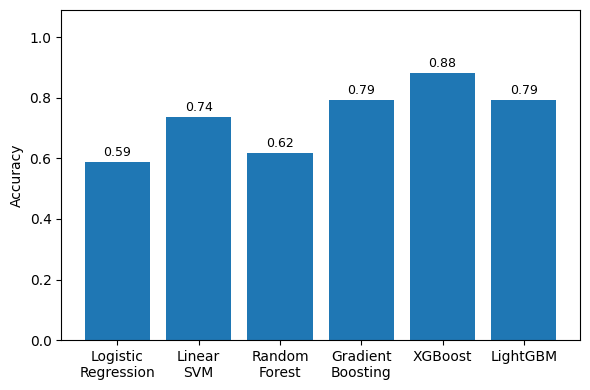

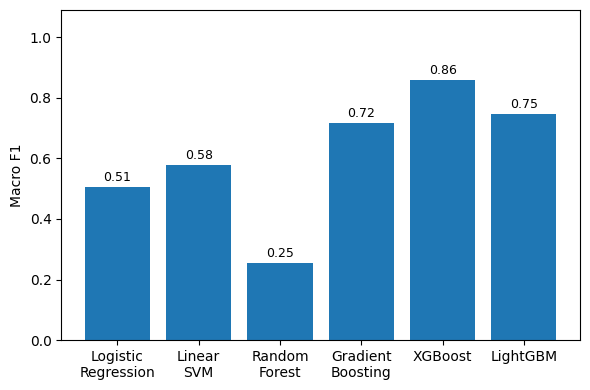

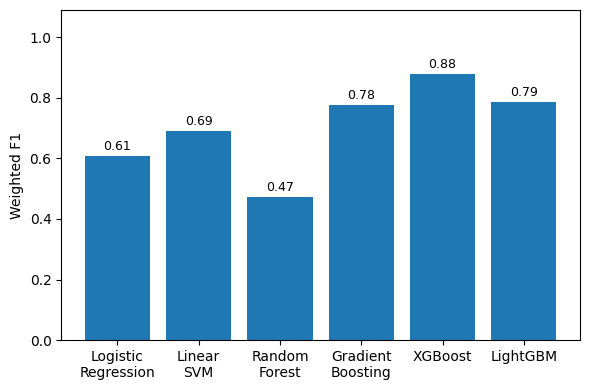

In [20]:
%matplotlib inline
def plot_model_comparison(results_df: pd.DataFrame):
    metrics = ["Accuracy", "Macro F1", "Weighted F1"]
    for metric in metrics:
        if metric not in results_df.columns:
            continue

        fig, ax = plt.subplots(figsize=(6, 4))
        bars = ax.bar(
            results_df["Model"],
            results_df[metric]
        )

        for bar, val in zip(bars, results_df[metric]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

        ax.set_ylim(0, 1.09)
        ax.set_ylabel(metric)
        ax.set_xticklabels(results_df["Model"], rotation=0, ha="center")
        plt.tight_layout()
        plt.show()

#model comparison graphs
plot_model_comparison(results_df)